In [3]:
!pip install arch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.2 MB/s eta 0:00:00


In [4]:
#Import Library
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import zscore
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)

from arch import arch_model

In [5]:
#Load Data
url = "https://raw.githubusercontent.com/RafRizu/epl-data-mining/refs/heads/main/final_matches.csv"
df = pd.read_csv(url)
df.head()

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,match report,notes,sh,sot,dist,fk,pk,pkatt,team,season
0,2020-09-12,12:30,Premier League,Matchweek 1,Sat,Away,W,3,0,Fulham,...,Match Report,NaN,13.0,5.0,14.1,2.0,0,0,Arsenal,2021
1,2020-09-19,20:00,Premier League,Matchweek 2,Sat,Home,W,2,1,West Ham,...,Match Report,NaN,7.0,3.0,14.8,0.0,0,0,Arsenal,2021
2,2020-09-28,20:00,Premier League,Matchweek 3,Mon,Away,L,1,3,Liverpool,...,Match Report,NaN,4.0,3.0,15.0,0.0,0,0,Arsenal,2021
3,2020-10-04,14:00,Premier League,Matchweek 4,Sun,Home,W,2,1,Sheffield Utd,...,Match Report,NaN,6.0,5.0,16.3,0.0,0,0,Arsenal,2021
4,2020-10-17,17:30,Premier League,Matchweek 5,Sat,Away,L,0,1,Manchester City,...,Match Report,NaN,11.0,3.0,18.4,2.0,0,0,Arsenal,2021


In [6]:
df.describe()

,gf,ga,xg,xga,poss,attendance,notes,sh,sot,dist,fk,pk,pkatt,season
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3102.000000,0.0,3800.000000,3800.000000,3799.000000,3800.000000,3800.000000,3800.000000,3800.0000
mean,1.457895,1.457895,1.404000,1.404000,50.000526,39007.501612,NaN,12.729474,4.276842,17.132087,0.408158,0.111842,0.136053,2023.0000
std,1.298273,1.298273,0.827715,0.827715,12.506971,17158.719815,NaN,5.594151,2.449101,2.950263,0.630861,0.339342,0.372332,1.4144
min,0.000000,0.000000,0.000000,0.000000,18.000000,2000.000000,NaN,0.000000,0.000000,5.300000,0.000000,0.000000,0.000000,2021.0000
25%,0.000000,0.000000,0.800000,0.800000,41.000000,27072.500000,NaN,9.000000,3.000000,15.200000,0.000000,0.000000,0.000000,2022.0000
50%,1.000000,1.000000,1.300000,1.300000,50.000000,36447.000000,NaN,12.000000,4.000000,17.000000,0.000000,0.000000,0.000000,2023.0000
75%,2.000000,2.000000,1.900000,1.900000,59.000000,53103.500000,NaN,16.000000,6.000000,18.900000,1.000000,0.000000,0.000000,2024.0000
max,9.000000,9.000000,7.000000,7.000000,82.000000,75546.000000,NaN,37.000000,16.000000,39.900000,4.000000,3.000000,3.000000,2025.0000


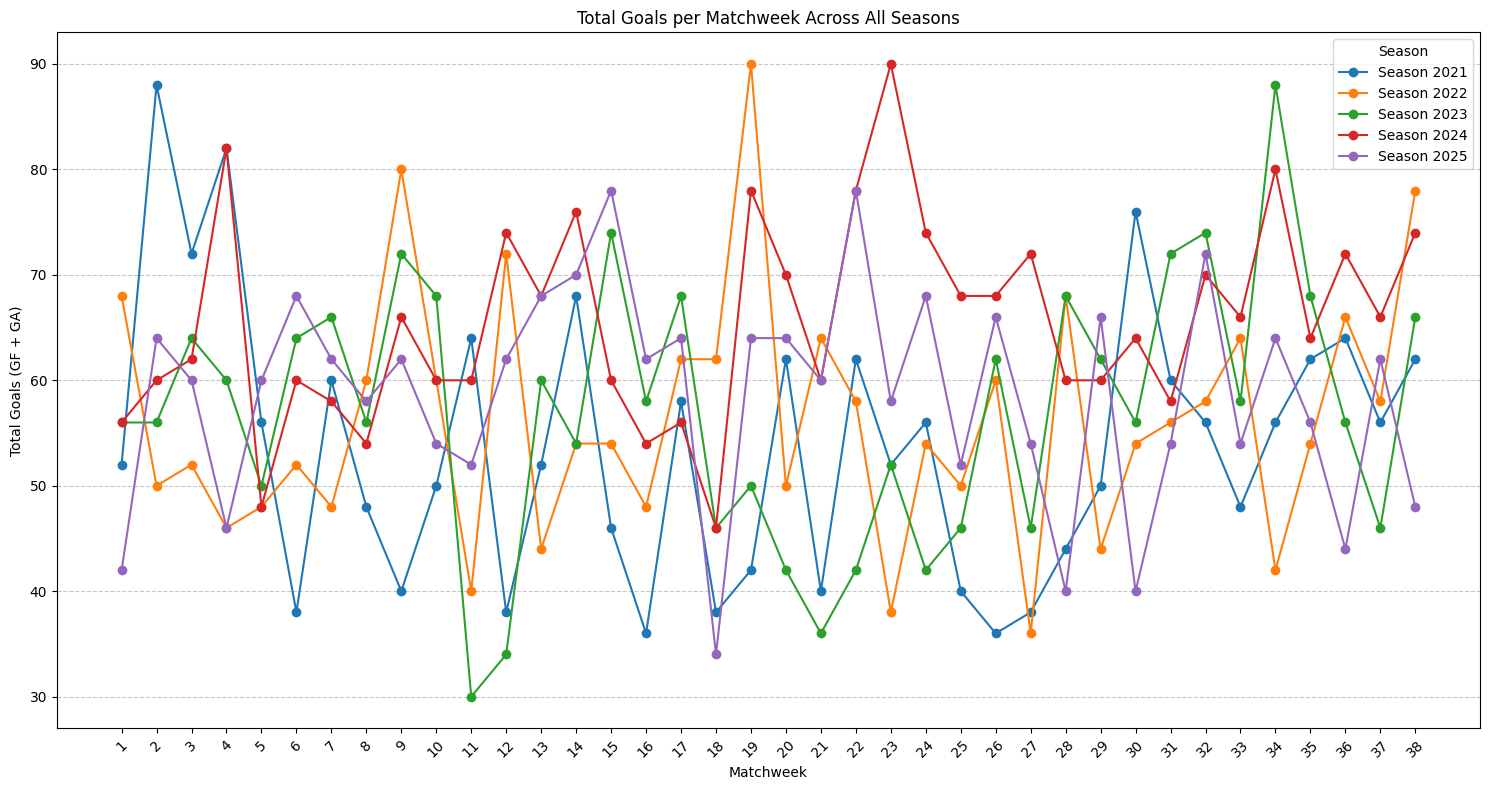

In [7]:
import re

# Extract matchweek number from the 'round' column for the entire DataFrame
df['matchweek_num'] = df['round'].apply(lambda x: int(re.search(r'\d+', x).group()) if pd.notnull(x) and re.search(r'\d+', x) else None)

# Filter out rows where matchweek_num could not be extracted (if any)
df_filtered = df.dropna(subset=['matchweek_num'])

# Get unique seasons
all_seasons = sorted(df_filtered['season'].unique())

plt.figure(figsize=(15, 8))

for season in all_seasons:
    # Filter data for the current season
    df_season = df_filtered[df_filtered['season'] == season]

    # Group by matchweek_num and sum goals (gf + ga)
    matchweek_goals_season = df_season.groupby('matchweek_num')[['gf', 'ga']].sum()
    matchweek_goals_season['total_goals'] = matchweek_goals_season['gf'] + matchweek_goals_season['ga']

    # Sort by matchweek_num to ensure correct plotting order
    matchweek_goals_season = matchweek_goals_season.sort_index()

    # Plot the line for the current season
    plt.plot(matchweek_goals_season.index, matchweek_goals_season['total_goals'], label=f'Season {season}', marker='o', linestyle='-')

plt.xlabel('Matchweek')
plt.ylabel('Total Goals (GF + GA)')
plt.title('Total Goals per Matchweek Across All Seasons')
plt.xticks(sorted(df_filtered['matchweek_num'].unique()), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [8]:
df_all_time = []
all_seasons = sorted(df_filtered['season'].unique())

for season in all_seasons:
    df_season = df_filtered[df_filtered['season'] == season]
    matchweek_goals_season = df_season.groupby('matchweek_num')[['gf', 'ga']].sum()
    matchweek_goals_season['total_goals'] = matchweek_goals_season['gf'] + matchweek_goals_season['ga']
    matchweek_goals_season = matchweek_goals_season.sort_index()
    matchweek_goals_season['season'] = str(season).strip()
    df_all_time.append(matchweek_goals_season)

df_arima_ready = pd.concat(df_all_time).reset_index()

In [9]:
result = adfuller(df_arima_ready['total_goals'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data stasioner")
else:
    print("Data tidak stasioner")

ADF Statistic: -3.486462517397465
p-value: 0.008341648453028885
Data stasioner


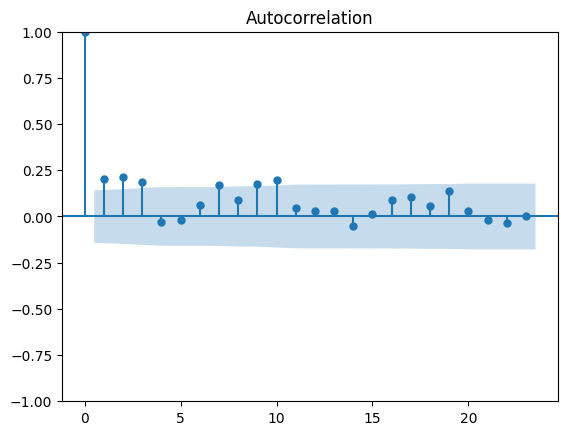

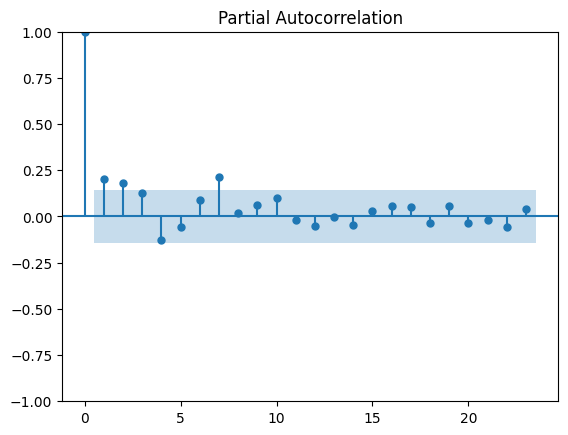

In [10]:
#Plot ACF dan PACF
plot_acf(df_arima_ready['total_goals'])
plt.show()

plot_pacf(df_arima_ready['total_goals'])
plt.show()

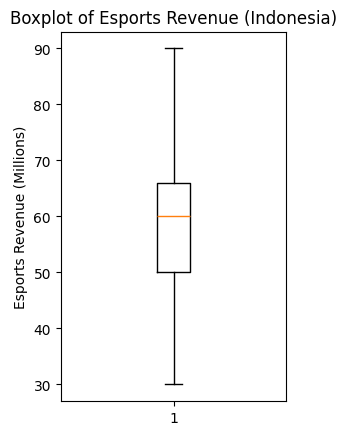

In [11]:
#Visualisasi Boxplot
plt.figure()

plt.subplot(1, 2, 1)
plt.boxplot(df_arima_ready['total_goals'])
plt.title("Boxplot of Esports Revenue (Indonesia)")
plt.ylabel("Esports Revenue (Millions)")

plt.show()

In [12]:
#Deteksi Outlier Metode IQR

series_to_analyze = df_arima_ready['total_goals']

Q1 = series_to_analyze.quantile(0.25)
Q3 = series_to_analyze.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_arima_ready[(series_to_analyze < lower_bound) | (series_to_analyze > upper_bound)]
outliers_iqr

,matchweek_num,gf,ga,total_goals,season


In [13]:
#Deteksi Outlier Metode Z-Score

series_to_analyze_z = df_arima_ready['total_goals']
z_scores = np.abs(zscore(series_to_analyze_z))

outliers_zscore = df_arima_ready[z_scores > 3]
outliers_zscore

,matchweek_num,gf,ga,total_goals,season


In [14]:
seasons_list = sorted(df_arima_ready['season'].unique())

# Musim terakhir (paling baru) dijadikan data TEST
test_season = seasons_list[-1]

# Musim-musim sebelumnya dijadikan data TRAIN
train_seasons = seasons_list[:-1]

# Lakukan filtering berdasarkan list di atas
df_train = df_arima_ready[df_arima_ready['season'].isin(train_seasons)]
df_test = df_arima_ready[df_arima_ready['season'] == test_season]

In [15]:
# model_arima = ARIMA(df_train['total_goals'].values, order=(3, 0, 2))
model_arima = ARIMA(df_train['total_goals'].values, order=(3, 0, 2))


arima_fit = model_arima.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  152
Model:                 ARIMA(3, 0, 2)   Log Likelihood                -586.863
Date:                Thu, 18 Jun 2026   AIC                           1187.727
Time:                        07:53:08   BIC                           1208.894
Sample:                             0   HQIC                          1196.325
                                - 152                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.3155      1.628     35.815      0.000      55.124      61.507
ar.L1          0.2994      0.274      1.091      0.275      -0.238       0.837
ar.L2         -0.4579      0.217     -2.109      0.0

In [16]:
residual = arima_fit.resid

In [17]:
#Uji Ljung-Box
lb_test = acorr_ljungbox(
    residual,
    lags=[10],
    return_df=True
)

print(lb_test)

if lb_test['lb_pvalue'].iloc[0] > 0.05:
    print("Residual tidak mengandung autokorelasi")
else:
    print("Residual masih mengandung autokorelasi")

     lb_stat  lb_pvalue
10  6.545125   0.767576
Residual tidak mengandung autokorelasi


In [18]:
#Uji Heteroskedastisitas
arch_test = het_arch(residual)

print("LM Statistic :", arch_test[0])
print("p-value      :", arch_test[1])

if arch_test[1] < 0.05:
    print("Terdapat efek ARCH")
else:
    print("Tidak terdapat efek ARCH")

LM Statistic : 9.990322977487635
p-value      : 0.44134269630080936
Tidak terdapat efek ARCH


In [19]:
steps = len(df_test)
forecast_result = arima_fit.forecast(steps=steps)

In [20]:
y_true = df_test['total_goals'].values
y_pred = forecast_result

mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("--- HASIL EVALUASI ARIMA(3,0,3) ---")
print(f"MAPE : {mape:.2f}%")
print(f"RMSE : {rmse:.2f} Gol")

--- HASIL EVALUASI ARIMA(3,0,3) ---
MAPE : 15.34%
RMSE : 10.30 Gol


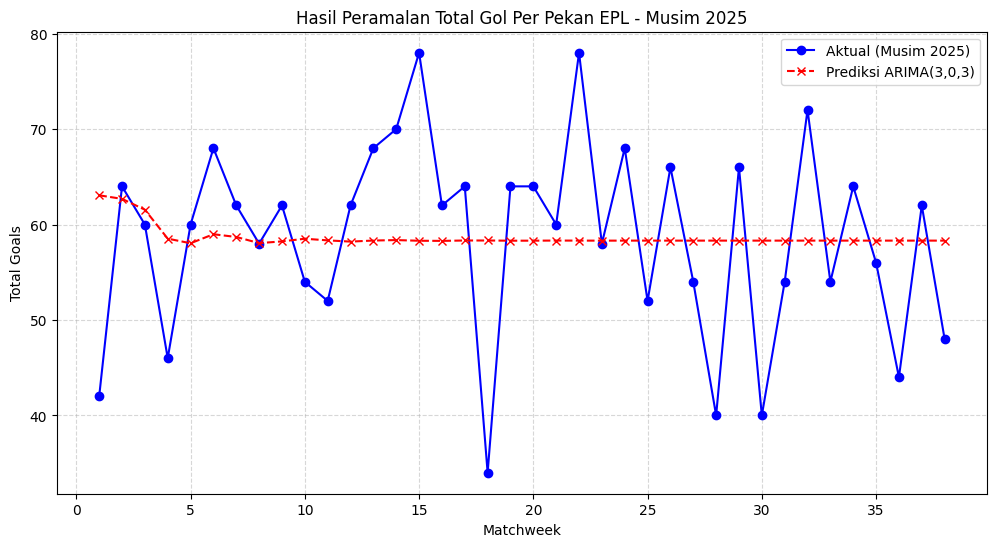

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df_test['matchweek_num'], y_true, label='Aktual (Musim 2025)', marker='o', color='blue')
plt.plot(df_test['matchweek_num'], y_pred, label='Prediksi ARIMA(3,0,3)', marker='x', linestyle='--', color='red')
plt.title('Hasil Peramalan Total Gol Per Pekan EPL - Musim 2025')
plt.xlabel('Matchweek')
plt.ylabel('Total Goals')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()